# Check for Normality
An important decision point when working with a sample of data is whether to use parametric or nonparametric statistical methods.

Parametric statistical methods assume that the data has a known and specific distribution, often a Gaussian distribution. If a data sample is not Gaussian, then the assumptions of parametric statistical tests are violated and nonparametric statistical methods must be used.

There are a range of techniques that you can use to check if your data sample deviates from a Gaussian distribution, called normality tests.

In [12]:
from numpy.random import seed, randn, rand
from numpy import mean, std

from matplotlib import pyplot
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot


seed(1)


In [2]:
# generate gaussian data

data = 5 * randn(100) + 50
print('mean=%.3f stdv=%.3f' % (mean(data), std(data)))

mean=50.303 stdv=4.426


## Histogram plot


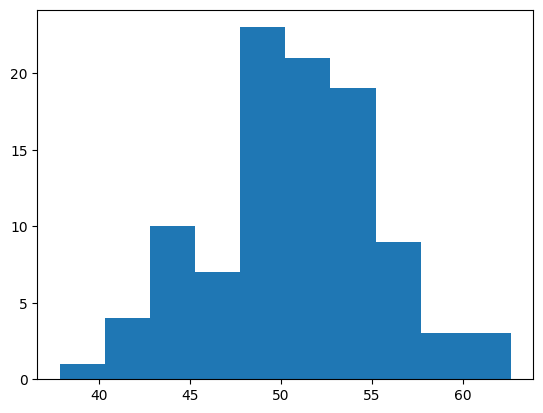

In [3]:
data = 5 * randn(100) + 50
pyplot.hist(data)
pyplot.show()

## Q-Q Plot Using statmodels


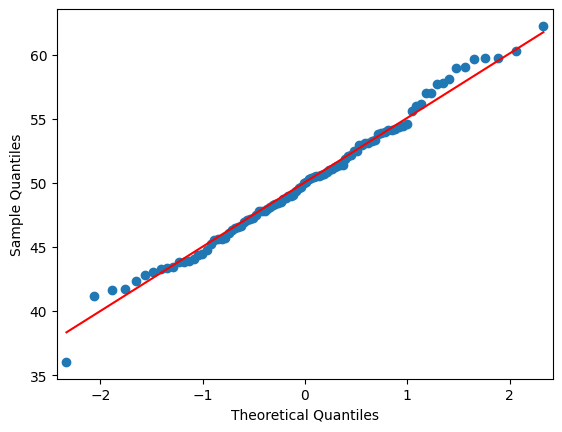

In [4]:
from statsmodels.graphics.gofplots import qqplot

data = 5 * randn(100) + 50
qqplot(data, line='s')
pyplot.show()

## Q-Q Plot Using scipy


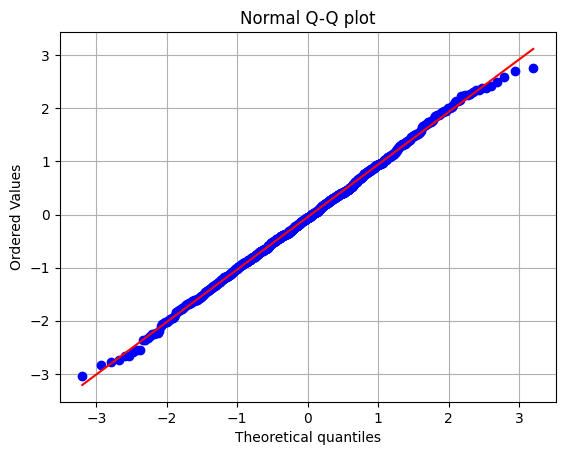

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate example data
np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=1000)

# Create Q-Q plot
stats.probplot(data, dist="norm", plot=plt)
plt.title('Normal Q-Q plot')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Ordered Values')
plt.grid(True)
plt.show()


## Shapiro-Wilk Test

In [14]:
# Shapiro-Wilk Test
from scipy.stats import shapiro

# generate univariate observations
data = 5 * randn(100) + 50
# normality test
stat, p = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
alpha = 0.05
if p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

Statistics=0.985, p=0.342
Sample looks Gaussian (fail to reject H0)


## D’Agostino’s K2 Test
The D’Agostino’s K2 test calculates summary statistics from the data, namely kurtosis and skewness, to determine if the data distribution departs from the normal distribution, named for Ralph D’Agostino.

- Skew is a quantification of how much a distribution is pushed left or right, a measure of asymmetry in the distribution.
- Kurtosis quantifies how much of the distribution is in the tail. It is a simple and commonly used statistical test for normality.

In [17]:
# D'Agostino and Pearson's Test
from scipy.stats import normaltest

# generate univariate observations
data = 5 * randn(100) + 50
# normality test
stat, p = normaltest(data)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

Statistics=1.399, p=0.497
Sample looks Gaussian (fail to reject H0)


## Anderson-Darling
A feature of the Anderson-Darling test is that it returns a list of critical values rather than a single p-value. This can provide the basis for a more thorough interpretation of the result.

In [19]:
# Anderson-Darling Test
from scipy.stats import anderson

# generate univariate observations
data = 5 * randn(100) + 50
# normality test
result = anderson(data)
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 0.456
15.000: 0.555, data looks normal (fail to reject H0)
10.000: 0.632, data looks normal (fail to reject H0)
5.000: 0.759, data looks normal (fail to reject H0)
2.500: 0.885, data looks normal (fail to reject H0)
1.000: 1.053, data looks normal (fail to reject H0)
